In [ ]:
import os, shutil, random
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2

In [ ]:
# 1. Dataset Preparation
original_data_dir = 'd:/PlantVillage'
base_dir = 'data'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

def prepare_data():
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    os.makedirs(train_dir), os.makedirs(val_dir), os.makedirs(test_dir)
    
    for class_name in os.listdir(original_data_dir):
        class_path = os.path.join(original_data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        images = os.listdir(class_path)
        random.shuffle(images)
        split1 = int(0.7 * len(images))
        split2 = int(0.85 * len(images))
        train_imgs, val_imgs, test_imgs = images[:split1], images[split1:split2], images[split2:]

        for split, folder in zip([train_imgs, val_imgs, test_imgs], [train_dir, val_dir, test_dir]):
            os.makedirs(os.path.join(folder, class_name), exist_ok=True)
            for img in split:
                shutil.copy(os.path.join(class_path, img), os.path.join(folder, class_name, img))

prepare_data()

In [ ]:
# 2. Preprocessing & Data Loading
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode='categorical')
val_gen = test_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode='categorical')
test_gen = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=batch_size, class_mode='categorical', shuffle=False)

num_classes = train_gen.num_classes

Found 14440 images belonging to 15 classes.
Found 3097 images belonging to 15 classes.
Found 3101 images belonging to 15 classes.


In [ ]:
# 3. Class Balancing
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(class_weights))

In [ ]:
# 4. Build ResNet50 Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [ ]:
# 5. Initial Training
model.fit(train_gen, validation_data=val_gen, epochs=25, class_weight=class_weights, callbacks=callbacks)


Epoch 1/25


452/452 [==============================] - ETA: 0s - loss: 0.8696 - accuracy: 0.7220

C:\Users\nensi\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


452/452 [==============================] - 962s 2s/step - loss: 0.8696 - accuracy: 0.7220 - val_loss: 0.3915 - val_accuracy: 0.8712 - lr: 0.0010
Epoch 2/25
452/452 [==============================] - 880s 2s/step - loss: 0.4545 - accuracy: 0.8447 - val_loss: 0.3539 - val_accuracy: 0.8831 - lr: 0.0010
Epoch 3/25
452/452 [==============================] - 885s 2s/step - loss: 0.3655 - accuracy: 0.8770 - val_loss: 0.2655 - val_accuracy: 0.9102 - lr: 0.0010
Epoch 4/25
452/452 [==============================] - 926s 2s/step - loss: 0.3591 - accuracy: 0.8787 - val_loss: 0.2425 - val_accuracy: 0.9193 - lr: 0.0010
Epoch 5/25
452/452 [==============================] - 880s 2s/step - loss: 0.3248 - accuracy: 0.8884 - val_loss: 0.2981 - val_accuracy: 0.9028 - lr: 0.0010
Epoch 6/25
452/452 [==============================] - 897s 2s/step - loss: 0.2778 - accuracy: 0.8986 - val_loss: 0.2889 - val_accuracy: 0.9122 - lr: 0.0010
Epoch 7/25
452/452 [==============================] - 868s 2s/step - loss: 

In [ ]:

# 6. Fine-tuning Top Layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights, callbacks=callbacks)


In [ ]:
# 7. Evaluation
test_gen.reset()
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

97/97 [==============================] - 99s 1s/step

=== Classification Report ===
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       150
                     Pepper__bell___healthy       1.00      1.00      1.00       222
                      Potato___Early_blight       0.99      0.97      0.98       150
                       Potato___Late_blight       0.95      0.98      0.96       150
                           Potato___healthy       0.95      0.91      0.93        23
                      Tomato_Bacterial_spot       0.99      0.94      0.96       320
                        Tomato_Early_blight       0.95      0.84      0.89       150
                         Tomato_Late_blight       0.95      0.96      0.96       287
                           Tomato_Leaf_Mold       0.95      0.92      0.94       143
                  Tomato_Septoria_leaf_spot       0.96      0.96 

In [ ]:
# 8. Grad-CAM Visualization
def get_img_array(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return preprocess_input(array)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block3_out'):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
# Visualize Grad-CAM
img_path = 'd:/PlantVillage/Tomato_Bacterial_spot/0ad88d7a-c14a-4ac9-8520-c11a0ade3a8f___UF.GRC_BS_Lab Leaf 0996.JPG'
img_array = get_img_array(img_path)
heatmap = make_gradcam_heatmap(img_array, model)

img = cv2.imread(img_path)
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
cv2.imwrite("gradcam_output.jpg", superimposed_img)

True

In [ ]:
# 9. Save Final Model
model.save("final_crop_disease_model.h5")

C:\Users\nensi\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 91ms/step
Predicted Class: Potato___Late_blight
Confidence: 100.0%


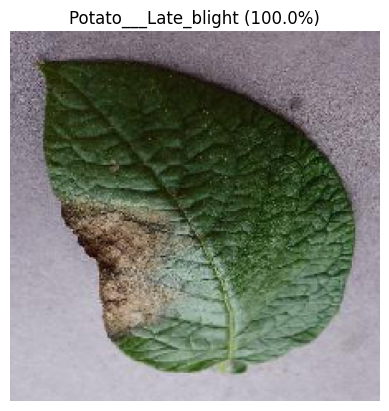

In [ ]:
# Prediction
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

#model = tf.keras.models.load_model("final_crop_disease_model.h5")

class_indices = {
    0: 'Pepper__bell___Bacterial_spot',
    1: 'Pepper__bell___healthy',
    2: 'Potato___Early_blight',
    3: 'Potato___Late_blight',
    4: 'Potato___healthy',
    5: 'Tomato_Bacterial_spot',
    6: 'Tomato_Early_blight',
    7: 'Tomato_Late_blight',
    8: 'Tomato_Leaf_Mold',
    9: 'Tomato_Septoria_leaf_spot',
    10: 'Tomato_Spider_mites_Two_spotted_spider_mite',
    11: 'Tomato__Target_Spot',
    12: 'Tomato__Tomato_YellowLeaf__Curl_Virus',
    13: 'Tomato__Tomato_mosaic_virus',
    14: 'Tomato_healthy'
}

def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array, img

def predict_disease(img_path):
    img_array, raw_img = prepare_image(img_path)
    preds = model.predict(img_array)
    pred_index = np.argmax(preds[0])
    pred_class = class_indices[pred_index]
    confidence = round(preds[0][pred_index] * 100, 2)

    print(f"Predicted Class: {pred_class}")
    print(f"Confidence: {confidence}%")

    plt.imshow(raw_img)
    plt.title(f"{pred_class} ({confidence}%)")
    plt.axis('off')
    plt.show()

predict_disease("d:/PlantVillage/Potato___Late_blight/04bbcc55-93d3-4a19-9137-8de036a8a4db___RS_LB 2647.JPG")  # Replace with your test image path
